### EAO - easy and straight forward optimization of energy setups

#### Import required packages

In [1]:
import math
import numpy as np
import pandas as pd
import datetime as dt
#import matplotlib.pyplot as plt

import eaopack as eao

#### Load data & make assumptions
In this case we load a month of quarter-hourly data. We will use day ahead prices as well as PV production profiles.

In [2]:
data = pd.read_csv('bess_netherlands.csv', parse_dates=True)

######################### battery settings
battery_data = {} # capacity, size and efficiency of an on-site battery
battery_data['cap']  =  15.0 # 15 MW
battery_data['size'] = 2.0 * battery_data['cap'] # 2 hours
battery_data['eff']  = 0.909 # 90.9% round-trip efficiency

######################### pv settings
subsidy = 0.0 # subsidy for PV feed-in (€/MWh). This is used to floor the PV price at a certain level.

######################### grid fee settings
grid_fee = 0.01 # grid fee (€/MWh). This is used to add a cost for consumption from the grid.



For the actual optimization we need to do some settings: Defining the time grid for optimization and defining which data to use in our assets.

In [3]:
######## prepare everything
## basics
S = pd.Timestamp(2026,6,1, tz='CET')
E = pd.Timestamp(2026,6,30, tz='CET')
timegrid = eao.Timegrid(S, E, freq = '15min', timezone='CET') # quarter-hourly

## settings
input_ts = pd.DataFrame()
input_ts['pv_prod']    =  4*data['MWH'] # MW
input_ts['dah'] =  data['DA'] # €/MWh
input_ts['id1'] =  data['ID1'] # €/MWh
input_ts['id3'] =  data['ID3'] # €/MWh

# cast to timegrid
input_ts = timegrid.prices_to_grid(input_ts)

Now we define the structure of our optimization problem -- our portfolio. The assets may be physical assets such as the battery or contracts such as supply via the grid.

In [4]:
### Structural setup
behind_meter = eao.Node('behind meter')
front_of_meter = eao.Node('front of meter')

out_to_grid = eao.assets.Transport( name   = 'out_to_grid',  # limited grid connection capacity
                                        nodes  = [behind_meter, front_of_meter],
                                        min_cap = 0.0, 
                                        max_cap = 20.0)

in_from_grid = eao.assets.Transport( name   = 'in_from_grid',  # limited grid connection capacity
                                        nodes  = [front_of_meter, behind_meter],
                                        costs = grid_fee, # grid fee for consumption from the grid
                                        min_cap = 0.0, 
                                        max_cap = 5.0)

### Our own PV module. The PV production is given by the input time series. The PV feed-in is subsidized at a certain level (subsidy).
fixed_price = subsidy - input_ts['dah'].to_numpy()
fixed_price[fixed_price < 0] = 0.0 # only subsidize if the market price is below the subsidy level
pv          = eao.assets.RenewableAsset(name       = 'pv', 
                                        nodes      = behind_meter,
                                        profile    = input_ts['pv_prod'].to_numpy(),
                                        fixed_price = -fixed_price) # negative because it is a feed-in

### An on-site battery constituting out flexibility
battery     = eao.assets.Battery(       name       = 'battery',
                                        nodes      = behind_meter,
                                        cap_in     = battery_data['cap'],
                                        cap_out    = battery_data['cap'],                                        
                                        eff_in     = math.sqrt(battery_data['eff']),
                                        eff_out    = math.sqrt(battery_data['eff']),
                                        size       = battery_data['size'],
                                        max_cycles_no = 24, # max_cycles_no = 0.8 (choose the desired behavior)
                                        max_cycles_freq = '29d', # max_cycles_freq = 'd' (choose the desired behavior)
                                        start_level= 0.5 * battery_data['size'],
                                        end_level  = 0.5 * battery_data['size'],
                                        #block_size = 'd',   # daily optimization of battery (leaving it 1/2 full every day)
                                        no_simult_in_out = True) # Important: The battery may now charge and discharge at the same time and
                                                                  # "burn" power due to efficiency < 100%. This makes computation much faster (no MIP)

### Supply/feed-in via the dah market
market_dah  = eao.assets.SimpleContract(name = 'dah', 
                                        nodes       = front_of_meter, 
                                        price       = 'dah',
                                        min_cap     = -1000, # unlimited capacity for selling to the market
                                        max_cap     = 1000) # unlimited capacity for buying from the market

### Supply/feed-in via the id market
market_id = eao.assets.SimpleContract(  name = 'id', 
                                        nodes       = front_of_meter, 
                                        price       = 'id1',
                                        min_cap     = -1000, # unlimited capacity for selling to the market
                                        max_cap     = 1000) # unlimited capacity for buying from the market


### Market without constraints. This is used for benchmarking the battery optimization.
market_without_constraints = eao.assets.SimpleContract(    name = 'unconstrained_market', 
                                        nodes       = behind_meter, 
                                        price       = 'dah',
                                        min_cap     = -1000, # unlimited feed-in
                                        max_cap     = 1000)  # unlimited supply


# define the portfolio of all assets and contracts
portf = eao.Portfolio([market_dah, in_from_grid, out_to_grid, pv, battery])

This is how the portfolio looks like (see below). We could set it up in a more complex way (distinction into in-front-of-the-meter and behind-the-meter) to incorporate grid fees. Here we start in the most simple way.

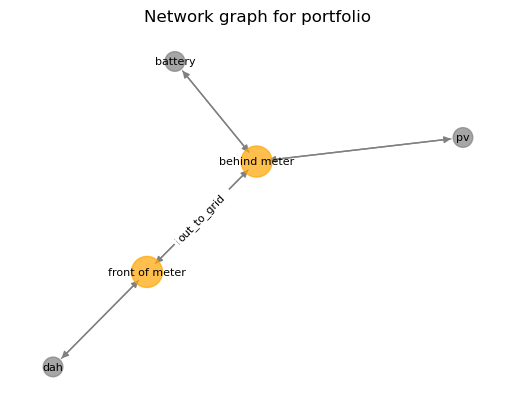

In [5]:
eao.network_graphs.create_graph(portf)

#### Optimization

The actual optimization is very simple. We collect all assets in the portfolio object and go. "extract_output" will generate straight-forward tables that can also be exported to Excel. Note that we are optimizing a full year on an hourly basis including a battery. This takes ~1 min.

In [6]:
out = eao.optimize(portf=portf, timegrid=timegrid, data=input_ts)
print(out['summary'])
eao.io.output_to_file(output=out, file_name='results_dah.xlsx') ### All details. Have look into the file

                  Values
Parameter               
status        successful
value      401399.510192


Defining the benchmark to calculate the value of the battery: The same portfolio without the battery

In [7]:
portf_pv_benchmark = eao.portfolio.Portfolio([market_without_constraints, pv])
out_pv_benchmark   = eao.optimize(portf=portf_pv_benchmark, timegrid=timegrid, data=input_ts)

portf_battery_benchmark = eao.portfolio.Portfolio([market_without_constraints, battery])
out_battery_benchmark   = eao.optimize(portf=portf_battery_benchmark, timegrid=timegrid, data=input_ts)

#### Interpretation of the results

Let us compare the overall revenues of the pv with and without battery

In [8]:
print(f'Overall revenues pv with battery:\t\t{out["summary"].loc["value", "Values"]:,.0f}')
print(f'Overall revenues pv only:\t\t\t{out_pv_benchmark["summary"].loc["value", "Values"]:,.0f}')
print(f'Overall revenues battery w/o constraints:\t{out_battery_benchmark["summary"].loc["value", "Values"]:,.0f}')
print(f'The battery increased the pv revenues by:\t{out["summary"].loc["value", "Values"] - out_pv_benchmark["summary"].loc["value", "Values"]:,.0f}')

Overall revenues pv with battery:		401,400
Overall revenues pv only:			238,015
Overall revenues battery w/o constraints:	163,991
The battery increased the pv revenues by:	163,385


#### Reoptimization in the intraday market

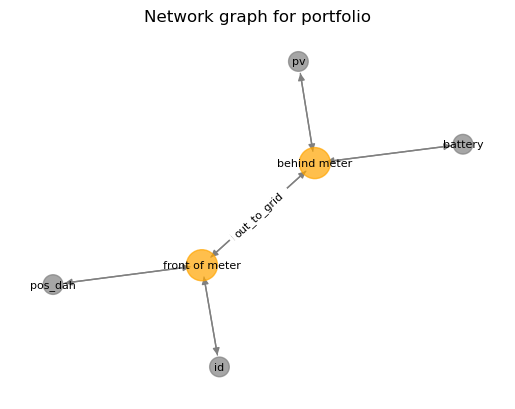

In [9]:
######### get dispatch for DAH and add this to the input for ID optimization
input_ts['pos_dah'] = 4*out['dispatch']['dah (front of meter)'] # MW
input_ts = timegrid.prices_to_grid(input_ts)

# new ID portfolio with position from dah
pos_dah = eao.assets.SimpleContract(name    = 'pos_dah',
                                          nodes   = front_of_meter,
                                          min_cap = 'pos_dah',
                                          max_cap = 'pos_dah')
portf_combined = eao.portfolio.Portfolio([market_id, in_from_grid, out_to_grid, pv, battery, pos_dah])
eao.network_graphs.create_graph(portf_combined)


In [10]:
# optimization run
out_dah_id   = eao.optimize(portf_combined, timegrid=timegrid, data = input_ts)

# merge the results of the dah and id optimization to get the overall revenues
out_dah_id['summary'].loc['id_value'] = out_dah_id['summary'].loc['value']
out_dah_id['summary'].loc['dah_value'] = out['summary'].loc['value']
out_dah_id['summary'].loc['value'] = out_dah_id['summary'].loc['value'] + out['summary'].loc['value']
out_dah_id['DCF']['dah']=out['DCF']['dah']

print(out_dah_id['summary'])
eao.io.output_to_file(output=out_dah_id, file_name='results_dah_id.xlsx') ### All details. Have look into the file

                  Values
Parameter               
status        successful
value      478020.755052
id_value     76621.24486
dah_value  401399.510192
